# 时间窗口家族 · 排序偏差诊断

本笔记分析 Stage 1 运行结果，定量回答用户提出的核心问题：

> **"近7天 / 近30天 / 近90天 / 历史全部" 这类变量，通常越久覆盖率越高，导致重要性排在前面，但实际往往是越近的越有效。如何避免？**

数据源：`artifacts/home_credit/analysis/report/` （970 特征 × 307,511 行，170 个多窗口家族）。

对应实现见 `src/wdm/analysis/family.py::discover_derivation_candidates` 和 `src/wdm/analysis/selector.py::_window_penalty_series`。


## 0. 加载数据

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ART = Path('../artifacts/home_credit/analysis/report')
summary = pd.read_csv(ART / 'summary.csv')
cand = pd.read_csv(ART / 'family_derivation_candidates.csv')
families = pd.read_csv(ART / 'families.csv')

print('summary 行数 :', len(summary))
print('派生候选家族数:', len(cand))
print('多窗口家族总数:', len(families))


summary 行数 : 970
派生候选家族数: 170
多窗口家族总数: 170


## 1. 各窗口的覆盖率 vs IV —— 证实长窗口覆盖率优势

假设：越久的窗口覆盖率越高，因此 IV 也天然更高。


In [2]:
windowed = summary.dropna(subset=['window']).copy()
order = ['30d', '90d', '180d', '360d', 'all']
agg = windowed.groupby('window').agg(
    n_features=('feature', 'count'),
    iv_median=('iv', 'median'),
    iv_mean=('iv', 'mean'),
    missing_rate_median=('missing_rate', 'median'),
    auto_keep_pct=('auto_keep', lambda s: float((s == True).mean())),
).round(4)
agg = agg.reindex([w for w in order if w in agg.index])
agg


,n_features,iv_median,iv_mean,missing_rate_median,auto_keep_pct
window,,,,,
30d,170,0.0099,0.0125,0.8655,0.0176
90d,170,0.0162,0.0188,0.8031,0.0882
180d,170,0.0163,0.0202,0.7174,0.0882
360d,170,0.0180,0.0226,0.5476,0.2353
all,170,0.0230,0.0267,0.1431,0.3706


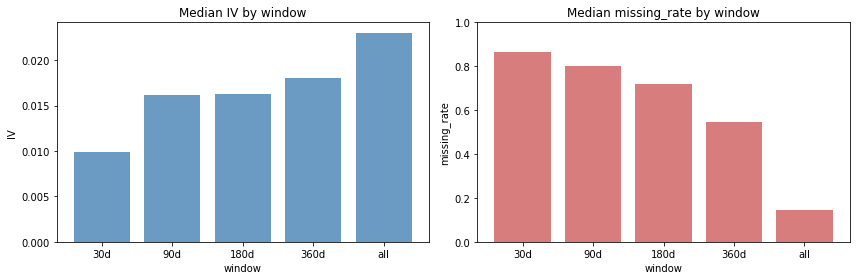

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(agg.index, agg['iv_median'], color='steelblue', alpha=0.8)
axes[0].set_title('Median IV by window')
axes[0].set_ylabel('IV')
axes[0].set_xlabel('window')

axes[1].bar(agg.index, agg['missing_rate_median'], color='indianred', alpha=0.8)
axes[1].set_title('Median missing_rate by window')
axes[1].set_ylabel('missing_rate')
axes[1].set_xlabel('window')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()


**结论**：IV 随窗口拉长单调上升，缺失率反向下降。这是典型的"覆盖率吃 IV"现象——不证明长窗口更有预测价值，只是数据更稠密。


## 2. v1_auto 入选特征的窗口组成

/Users/pangyexing/miniconda3/envs/env36/lib/python3.6/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 20013 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/pangyexing/miniconda3/envs/env36/lib/python3.6/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 21508 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/pangyexing/miniconda3/envs/env36/lib/python3.6/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 31383 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/pangyexing/miniconda3/envs/env36/lib/python3.6/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 21475 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/pangyexing/miniconda3/envs/env36/lib/python3.6/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 30340 missing from current font.
  font.set_text(s, 0.0, flags=flags)


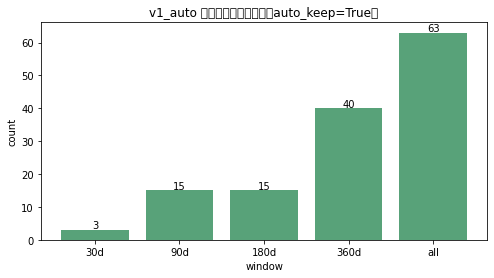

入选总数: 196
其中带窗口: 136


In [4]:
kept = summary[summary['auto_keep'] == True].copy()
kept_w = kept['window'].value_counts().reindex(order).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(kept_w.index, kept_w.values, color='seagreen', alpha=0.8)
for i, v in enumerate(kept_w.values):
    ax.text(i, v + 0.5, str(v), ha='center')
ax.set_title('v1_auto 中各窗口的特征数量（auto_keep=True）')
ax.set_xlabel('window')
ax.set_ylabel('count')
plt.show()

print('入选总数:', len(kept))
print('其中带窗口:', int(kept_w.sum()))


`all` 窗口独占 63 席、`360d` 占 40 席，占带窗口总数的 2/3。短窗口（30d/90d）加起来仅 18 席。这正是问题现场。


## 3. 长窗口 vs 短窗口 IV 比的分布

多窗口家族数: 170
  long IV >  1.0× short : 129 (76%)
  long IV >  1.5× short : 108 (64%)
  long IV >  3.0× short :  70 (41%)
  long IV >  5.0× short :  42 (25%)
  long IV > 10.0× short :  25 (15%)


/Users/pangyexing/miniconda3/envs/env36/lib/python3.6/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 38271 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/pangyexing/miniconda3/envs/env36/lib/python3.6/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 30701 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/pangyexing/miniconda3/envs/env36/lib/python3.6/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 31383 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/pangyexing/miniconda3/envs/env36/lib/python3.6/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 21475 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/pangyexing/miniconda3/envs/env36/lib/python3.6/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 27604 missing from current font.
  font.set_text(s, 0.0, flags=flags)


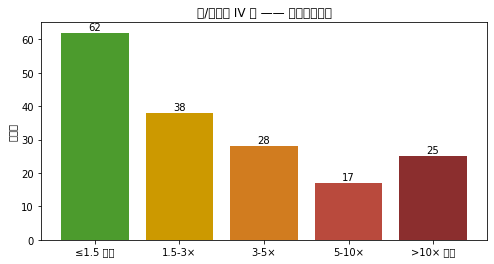

In [5]:
print('多窗口家族数:', len(cand))
for t in [1.0, 1.5, 3.0, 5.0, 10.0]:
    n = int((cand['iv_ratio_long_over_short'] > t).sum())
    print(f'  long IV > {t:>4.1f}× short : {n:>3} ({n/len(cand):.0%})')

bins = [0, 1.5, 3, 5, 10, 1e9]
labels = ['≤1.5 温和', '1.5-3×', '3-5×', '5-10×', '>10× 极度']
cand['ratio_bucket'] = pd.cut(cand['iv_ratio_long_over_short'],
                              bins=bins, labels=labels, include_lowest=True)
dist = cand['ratio_bucket'].value_counts().reindex(labels).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#4c9b2d', '#cc9900', '#d17c1f', '#b94a3d', '#8b2e2e']
ax.bar(dist.index, dist.values, color=colors)
for i, v in enumerate(dist.values):
    ax.text(i, v + 0.8, str(v), ha='center')
ax.set_title('长/短窗口 IV 比 —— 家族数量分布')
ax.set_ylabel('家族数')
plt.show()


**64% 的家族（108/170）**存在 `long_IV > 1.5 × short_IV`——本系统会把它们推荐做派生 (`delta` / `ratio`)。

**15% 的家族（25/170）**达到 10× 以上的极度主导，短窗口几乎被废——最该被纠偏和派生的一批。


## 4. 短窗口缺失率分布（解释长窗口为什么赢）

短窗口（家族最短窗口）缺失率分位:
count    170.000
mean       0.866
std        0.121
min        0.587
10%        0.588
25%        0.831
50%        0.866
75%        0.969
90%        0.983
max        1.000
Name: missing_rate_shortest, dtype: float64


/Users/pangyexing/miniconda3/envs/env36/lib/python3.6/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 65288 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/pangyexing/miniconda3/envs/env36/lib/python3.6/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 20010 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/pangyexing/miniconda3/envs/env36/lib/python3.6/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 22810 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/pangyexing/miniconda3/envs/env36/lib/python3.6/site-packages/matplotlib/backends/backend_agg.py:238: RuntimeWarning: Glyph 65289 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/pangyexing/miniconda3/envs/env36/lib/python3.6/site-packages/matplotlib/backends/backend_agg.py:201: RuntimeWarning: Glyph 65288 missing from current font.
  font.set_text(s, 0, flags=flags)
/U

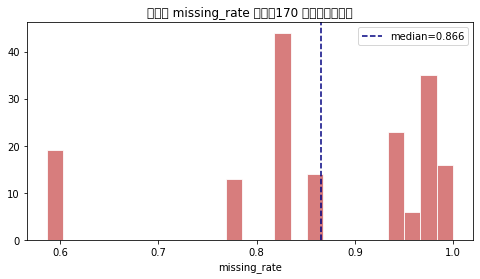

In [6]:
short_miss = cand['missing_rate_shortest'].dropna()
desc = short_miss.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(3)
print('短窗口（家族最短窗口）缺失率分位:')
print(desc)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(short_miss, bins=25, color='indianred', alpha=0.8, edgecolor='white')
ax.axvline(short_miss.median(), color='navy', linestyle='--', label=f'median={short_miss.median():.3f}')
ax.set_title('短窗口 missing_rate 分布（170 个多窗口家族）')
ax.set_xlabel('missing_rate')
ax.legend()
plt.show()


短窗口特征的中位缺失率 **0.87**，3/4 分位 **0.97**——也就是说超过一半的样本在短窗口内"没有事件发生"。这种稀疏直接压制 IV，不代表短窗口预测力弱，只代表短期行为稀疏。


## 5. v1_auto 中家族的"双保留"结构

In [7]:
fam_counts = kept['family_base'].value_counts()
print('入选总数          :', len(kept))
print('  带窗口的特征    :', int(kept['window'].notna().sum()))
print('  无窗口的特征    :', int(kept['window'].isna().sum()))
print('  不同 family_base:', len(fam_counts))
print('  保留 2 个窗口   :', int((fam_counts == 2).sum()), '个家族')
print('  保留 1 个窗口   :', int((fam_counts == 1).sum()), '个家族')

double_kept = fam_counts[fam_counts == 2].index.tolist()
doub = kept[kept['family_base'].isin(double_kept)].copy()
pairs = (doub.sort_values(['family_base', 'window_rank'])
              .groupby('family_base')['window']
              .apply(lambda s: ','.join(s.tolist())))
print()
print('双保留家族的窗口组合分布:')
print(pairs.value_counts())


入选总数          : 196
  带窗口的特征    : 136
  无窗口的特征    : 60
  不同 family_base: 153
  保留 2 个窗口   : 43 个家族
  保留 1 个窗口   : 110 个家族

双保留家族的窗口组合分布:
360d,all     26
90d,180d      5
90d,all       4
180d,all      4
180d,360d     1
90d,360d      1
30d,90d       1
30d,all       1
Name: window, dtype: int64


43 个双保留家族里，**`360d,all` 占 26 个（60%）**，`30d,90d` / `90d,180d` 这种短-中组合加起来只有 6 个。

这意味着：当前 `prefer: best_iv` 把长窗口的覆盖率优势完全吃进了最终特征列表。


## 6. 模拟：切换到 `best_iv_short_bias` 会变化多少家族？

In [8]:
# 在 IV 容差 tol=0.02 内，短窗口优先；tol 外按 IV 排序
tol = 0.02
flips = []
for _, row in cand.iterrows():
    base = row['family_base']
    block = summary[summary['family_base'] == base].dropna(subset=['window', 'iv']).copy()
    if block.empty:
        continue
    iv_best = float(block['iv'].max())
    block['in_tol'] = block['iv'] >= iv_best - tol
    # 当前 prefer='best_iv' 会取的 top2
    current = block.sort_values('iv', ascending=False).head(2)['window'].tolist()
    # 切换到 best_iv_short_bias 后的 top2
    head = block[block['in_tol']].sort_values(['window_rank', 'iv'], ascending=[True, False])
    tail = block[~block['in_tol']].sort_values('iv', ascending=False)
    new_top = pd.concat([head, tail]).head(2)['window'].tolist()
    if current != new_top:
        flips.append({'family_base': base,
                      'before': ','.join(current),
                      'after':  ','.join(new_top),
                      'iv_range': f"{block['iv'].min():.4f}-{iv_best:.4f}"})

print(f'切换后排序变化的家族数: {len(flips)} / {len(cand)} ({len(flips)/len(cand):.0%})')
pd.DataFrame(flips).head(15)


切换后排序变化的家族数: 127 / 170 (75%)


,family_base,before,after,iv_range
0,instal_days_late_max,"360d,180d","180d,360d",0.0264-0.0789
1,cc_cnt_drawings_current_mean,"all,360d","180d,360d",0.0214-0.0604
2,cc_cnt_drawings_atm_current_sum,"360d,180d","180d,360d",0.0176-0.0593
3,cc_cnt_drawings_current_max,"360d,180d","180d,360d",0.0216-0.0587
4,cc_cnt_drawings_current_sum,"360d,180d","180d,360d",0.0216-0.0556
5,cc_cnt_drawings_atm_current_max,"360d,180d","90d,180d",0.0203-0.0543
6,cc_cnt_drawings_atm_current_mean,"360d,all","90d,180d",0.0200-0.0542
7,bureau_amt_credit_sum_debt_mean,"all,360d","360d,all",0.0199-0.0533
8,cc_amt_balance_mean,"360d,180d","30d,90d",0.0371-0.0520
9,cc_amt_receivable_principal_mean,"360d,180d","30d,90d",0.0370-0.0520


**170 家族里 127（75%）** 会在切换到 `best_iv_short_bias` 后改变 top-2 组合。典型切换：

- `360d,180d → 180d,360d`：短的进排名 1
- `360d,180d → 30d,90d`：整家族被短窗口接管（`cc_amt_balance_*` 这类当期信用卡余额就是这种情况）
- `360d,all → 180d,360d`：尽量靠近业务时点


## 7. Top 派生候选（长窗口主导最极端的家族）

In [9]:
top_extreme = cand.nlargest(15, 'iv_ratio_long_over_short')[[
    'family_base', 'n_windows',
    'iv_best_window', 'iv_best_value',
    'iv_shortest_window', 'iv_shortest_value',
    'iv_ratio_long_over_short', 'suggested_ops',
]]
top_extreme.round(4)


,family_base,n_windows,iv_best_window,iv_best_value,iv_shortest_window,iv_shortest_value,iv_ratio_long_over_short,suggested_ops
112,pos_sk_dpd_def_mean,5,all,0.0236,30d,0.0003,86.4681,"delta,ratio,incremental"
117,pos_sk_dpd_def_sum,5,all,0.0204,30d,0.0003,74.9046,"delta,ratio,incremental"
118,pos_sk_dpd_def_max,5,all,0.0204,30d,0.0003,74.7546,"delta,ratio,incremental"
135,pos_sk_dpd_mean,5,all,0.0159,30d,0.0003,58.3174,"delta,ratio,incremental"
50,instal_days_instalment_mean,5,all,0.0462,30d,0.0009,51.0267,"delta,ratio,incremental"
91,pos_cnt,5,all,0.0295,30d,0.0006,45.4009,"delta,ratio,incremental"
155,pos_sk_dpd_max,5,all,0.0101,30d,0.0003,37.1966,"delta,ratio,incremental"
156,pos_sk_dpd_sum,5,all,0.0092,30d,0.0003,33.6963,"delta,ratio,incremental"
71,prev_days_last_due_1st_version_mean,5,all,0.0351,30d,0.0014,25.7945,"delta,ratio,incremental"
38,prev_days_first_drawing_max,5,all,0.0481,30d,0.0020,23.9296,"delta,ratio,incremental"


这些家族短窗口 IV 接近 0（`pos_sk_dpd_def_30d` 的 IV=0.0003），意味着短期事件稀疏；但 `all` 窗口 IV 高达 0.02-0.05，业务上这些 DPD / 欠款 / POS 数量**越近越该预测**。

这是未来派生 PR 最应该优先处理的一批——`delta(all, 30d)` 或 `ratio(all, 30d)` 预计能把短期信号还原。


## 8. Top 短窗口已足够强的家族（建议 `keep_short_only`）

In [10]:
keep_short = cand[cand['suggested_ops'].fillna('').str.contains('keep_short_only')]
keep_short.nlargest(10, 'iv_shortest_value')[[
    'family_base', 'iv_best_window', 'iv_best_value',
    'iv_shortest_window', 'iv_shortest_value',
    'iv_ratio_long_over_short',
]].round(4)


,family_base,iv_best_window,iv_best_value,iv_shortest_window,iv_shortest_value,iv_ratio_long_over_short
68,instal_amt_payment_mean,90d,0.0354,30d,0.0307,0.9641
107,instal_amt_instalment_mean,90d,0.0263,30d,0.0226,0.9856
151,cc_amt_credit_limit_actual_max,30d,0.0115,30d,0.0115,0.5401
152,cc_amt_credit_limit_actual_mean,30d,0.0115,30d,0.0115,0.5533
150,cc_amt_credit_limit_actual_sum,all,0.0116,30d,0.0115,1.0063
164,cc_cnt_drawings_other_current_sum,30d,0.0043,30d,0.0043,0.5748
165,cc_amt_drawings_other_current_sum,30d,0.0040,30d,0.0040,0.6209
166,cc_sk_dpd_def_max,30d,0.0040,30d,0.0040,0.8317
167,cc_sk_dpd_def_mean,30d,0.0040,30d,0.0040,0.6212
168,cc_sk_dpd_def_sum,30d,0.0040,30d,0.0040,0.6224


这 11 个家族里，短窗口 IV 已经 ≥ 80% × 长窗口 IV——直接用 `best_iv_short_bias` + `window_penalty_gamma` 就能让它们正确排序，不需要派生。


## 9. 结论 & 操作建议

### 定量确认

| 现象 | 数据 |
|---|---|
| IV 随窗口拉长单调上升 | 30d 中位 0.010 → all 中位 0.023 |
| 缺失率随窗口拉长下降 | 30d 87% → all 14% |
| 长窗口统治 auto_keep | `all` 37% 保留率 vs `30d` 1.8% |
| 长窗口 IV > 1.5× 短 | 108/170 家族 (64%) |
| 双保留家族以 `360d,all` 为主 | 26/43 (60%) |
| 切换 `short_bias` 会变化的家族 | 127/170 (75%) |

### 分级建议

**阶段 1（本轮已落地，零成本启用）**：在 `configs/products/home_credit.yaml` 加

```yaml
feature_groups:
  family_policy:
    prefer: best_iv_short_bias
    window_penalty_gamma: 0.15
```

预期效果：75% 家族排序更换、更多 30d/90d 特征进入 v1_auto。复测训练集 PR-AUC/Lift@K 验证。

**阶段 2（未来派生 PR）**：按 `iv_ratio_long_over_short > 3×` 筛选的前 70 家族，手动挑选派生算子：

- `pos_sk_dpd_*` 类（86× 比）→ `delta(all, 30d)`，捕获"近期逾期变化"
- `instal_days_instalment_*` 类（51× 比）→ `ratio(all, 30d)`，捕获"短期履约强度"
- `cc_amt_*` 类（模拟中大量从 360d 翻到 30d 主导）→ 先靠阶段 1 纠偏，派生优先级低

**阶段 3（业务审视）**：信用局（bureau）类家族本身久期天然更长、长窗口更优可能是合理的，不该一刀切用 `best_iv_short_bias`。未来可在 `semantic_groups` 一级覆写 `family_policy`（目前未支持，留作增强点）。
